In [1]:
#import the necessary packages for all analysis
import pandas as pd
import numpy as np 
import warnings

warnings.filterwarnings(
    "ignore",
    message="Found unknown categories in columns*",
    category=UserWarning,
    module="sklearn.preprocessing._encoders"
)

In [2]:
#Import the data from Kaggle 
test_df = pd.read_csv('/Users/alextoy/Desktop/Kaggle Competitions /Titanic/titanic/test.csv')
train_df = pd.read_csv('/Users/alextoy/Desktop/Kaggle Competitions /Titanic/titanic/train.csv')

In [3]:
train_df.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


# Titanic Machine Learning - Logit with L1, L2, and Elastic Net Regularization

## L1 Regularization (Lasso)

In [4]:
#now import the sklearn packages for splitting the sample and for running the Logit analysis 
#for splitting test/train and for k-folds cross validation 
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV 

#to make transforming the data easier ColumnTransformer and Pipeline keep preprocessed data inside the folds 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#for encoding the data 
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import OneHotEncoder, StandardScaler

#to actually run the model 
from sklearn.linear_model import LogisticRegression 

#to test how well the model performs 
from sklearn.metrics import log_loss, roc_auc_score, accuracy_score 

In [5]:
#first create additional features
def add_titanic_features(df: pd.DataFrame) -> pd.DataFrame: 
    df = df.copy()

    #add log(fare) 
    df["log_Fare"] = np.log1p(df["Fare"])

    #family features (total size and if they're alone) 
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

    #title from name 
    df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)\.", expand = False).str.strip()
    df["Title"] = df["Title"].replace({
        "Mlle": "Miss", "Ms":"Miss","Mme":"Mrs"
    })
    df["Title"] = df["Title"].where(df["Title"].isin(["Mr","Mrs","Miss","Master"]), "Other")

    #Cabin Features 
    df["CabinKnown"] = df["Cabin"].notna().astype(int)
    df["Deck"] = df["Cabin"].str[0].fillna("Unknown")

    return df


In [6]:
#now add the additional covariates to the training data 
train_fe = add_titanic_features(train_df)

#define the feature list, then the X and y 
Feature_List = [
    "Pclass", "Sex", "Age",
    "log_Fare", "Embarked",
    "FamilySize", "IsAlone",
    "Title",
    "CabinKnown", "Deck",
]

X = train_fe[Feature_List]
y = train_fe["Survived"]

In [7]:
#now build the preprocessing 
numeric_features = ["Age","log_Fare","FamilySize"]
categorical_features = ["Pclass", "Sex", "Embarked", "IsAlone", "Title","CabinKnown", "Deck"]

#numeric preprocessing
numeric_transformer = Pipeline(steps = [("imputer", SimpleImputer(strategy  = "median", add_indicator = True)),
                                         ("scaler", StandardScaler())
                                         ])

#categorical preprocessing 
categorical_transformer = Pipeline(steps = [("imputer", SimpleImputer(strategy = "constant", fill_value = "Missing")),
                                             ("onehot", OneHotEncoder(handle_unknown = "ignore", drop = "first"))])

#preprocess 
preprocess = ColumnTransformer(transformers = [("num", numeric_transformer, numeric_features),
                                              ("cat",categorical_transformer, categorical_features)])


In [8]:
# Now run the L1 regularization Logit and the standard logit on the 80-20 test train split. 
#first split the data 
X_train, X_val, y_train, y_val = train_test_split(X,y,test_size = 0.2, random_state = 1234, stratify = y)

#now run the plain logit without regularization 
logit = Pipeline(steps = [
    ("preprocess", preprocess),
    ("model", LogisticRegression(penalty = None, max_iter = 5000))
])

logit.fit(X_train,y_train)
predicted_probability = logit.predict_proba(X_val)[:,1]
predicted_value = (predicted_probability > 0.5).astype(int)

logit_evaluation = {"log loss":log_loss(y_val, predicted_probability),
                   "ROC-AUC Score": roc_auc_score(y_val, predicted_probability),
                   "Accuracy": accuracy_score(y_val, predicted_value)}

#next run the L1 regularized logit (Lasso) and we'll loop over C to find the ideal regularization parameter 
lasso = Pipeline(steps = [
    ("preprocess", preprocess),
    ("model", LogisticRegression(penalty = "l1", solver = "liblinear", max_iter = 5000))
])

#now search the parameter space for the best C, to do this you do an inner k fold CV
parameter_grid = {"model__C": np.logspace(-3,2,10)} #this is the grid it's going to search over 
inner_cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 1234)

lasso_search = GridSearchCV(
    lasso, 
    param_grid = parameter_grid,
    scoring = "neg_log_loss", 
    cv = inner_cv, 
    n_jobs = -1)

lasso_search.fit(X_train,y_train)

best_lasso = lasso_search.best_estimator_

predicted_probability_lasso = best_lasso.predict_proba(X_val)[:,1]
predicted_value_lasso = (predicted_probability_lasso > 0.5).astype(int)

lasso_evaluation = {"best C":lasso_search.best_params_["model__C"],
                    "log loss":log_loss(y_val, predicted_probability_lasso),
                   "ROC-AUC Score": roc_auc_score(y_val, predicted_probability_lasso),
                   "Accuracy": accuracy_score(y_val, predicted_value_lasso)}

print(logit_evaluation)
print(lasso_evaluation)


{'log loss': 0.45475794869118946, 'ROC-AUC Score': 0.8483530961791831, 'Accuracy': 0.8156424581005587}
{'best C': np.float64(0.5994842503189409), 'log loss': 0.44927222242507187, 'ROC-AUC Score': 0.8525691699604744, 'Accuracy': 0.8156424581005587}


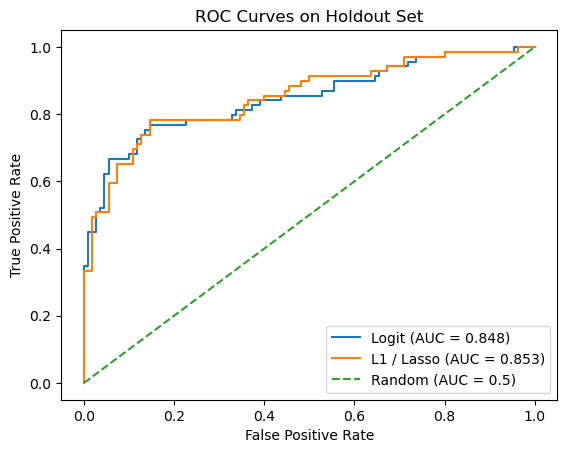

In [9]:
#Now plot the ROC-AUC for both models 
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# probabilities on the same validation set
proba_logit = logit.predict_proba(X_val)[:, 1]
proba_lasso = best_lasso.predict_proba(X_val)[:, 1]

# ROC points
fpr_logit, tpr_logit, _ = roc_curve(y_val, proba_logit)
fpr_lasso, tpr_lasso, _ = roc_curve(y_val, proba_lasso)

# AUC numbers
auc_logit = roc_auc_score(y_val, proba_logit)
auc_lasso = roc_auc_score(y_val, proba_lasso)

plt.figure()
plt.plot(fpr_logit, tpr_logit, label=f"Logit (AUC = {auc_logit:.3f})")
plt.plot(fpr_lasso, tpr_lasso, label=f"L1 / Lasso (AUC = {auc_lasso:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random (AUC = 0.5)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves on Holdout Set")
plt.legend()
plt.show()

In [10]:
#Next do K-Fold Cross Validation for each model. 
#first for the Logit
# Number of folds 
k = 5

#cross validation 
cv = StratifiedKFold(n_splits = k, shuffle = True, random_state = 1234) 

#Now get the model performance metrics we want to track and put them in a Dict 
scoring = {
    'logloss': 'neg_log_loss',
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy'}

#now run the cross validation 
cv_results = cross_validate(
    logit, X, y, 
    cv = cv, 
    scoring = scoring, 
    return_train_score = False 
)

#now get the measures for our 5 cross validations (convert neg log loss to positive as well)
logloss = -cv_results["test_logloss"]
roc_auc = cv_results["test_roc_auc"]
acc = cv_results["test_accuracy"]
print("Logit K-Fold Cross Validation Evaluation")
print(f"{k}-fold CV Log Loss: {logloss.mean():.4f} ± {logloss.std():.4f}")
print(f"{k}-fold CV ROC-AUC:  {roc_auc.mean():.4f} ± {roc_auc.std():.4f}")
print(f"{k}-fold CV Accuracy: {acc.mean():.4f} ± {acc.std():.4f}")

#now repeat for the Lasso (L1 Model)
#set up the outer k-fold and the inner k-fold. the outer is for model evaluation the inner is for c parameter choice 
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234)

#Set up the parameter grid same as before 
parameter_grid = {"model__C": np.logspace(-3,2,10)} #this is the grid it's going to search over 

#define the lasso pipeline 
lasso = Pipeline(steps = [
    ("preprocess", preprocess),
    ("model", LogisticRegression(penalty = "l1", solver = "liblinear", max_iter = 5000))
])

lasso_search = GridSearchCV(
    lasso, 
    param_grid = parameter_grid,
    scoring = "neg_log_loss", 
    cv = inner_cv, 
    n_jobs = -1)

#now run the cross validation 
cv_results_lasso = cross_validate(
    lasso_search, X, y, 
    cv = outer_cv, 
    scoring = scoring, #same scoring as above with the logit
    return_train_score = False 
)

#now calculate and print out the model quality 
print("Nested L1 5-fold CV")
print("Log loss:", (-cv_results_lasso["test_logloss"]).mean(), "±", (-cv_results_lasso["test_logloss"]).std())
print("ROC-AUC: ", (cv_results_lasso["test_roc_auc"]).mean(), "±", (cv_results_lasso["test_roc_auc"]).std())
print("Accuracy:", (cv_results_lasso["test_accuracy"]).mean(), "±", (cv_results_lasso["test_accuracy"]).std())

Logit K-Fold Cross Validation Evaluation
5-fold CV Log Loss: 0.4357 ± 0.0067
5-fold CV ROC-AUC:  0.8695 ± 0.0182
5-fold CV Accuracy: 0.8261 ± 0.0276
Nested L1 5-fold CV
Log loss: 0.4146797699453867 ± 0.02773046635061981
ROC-AUC:  0.8759951263023249 ± 0.018764571490306164
Accuracy: 0.8294206264515724 ± 0.013358159211793709


## Ridge

In [11]:
#next run the L2 regularized logit (Ridge) and we'll loop over C to find the ideal regularization parameter 
ridge = Pipeline(steps = [
    ("preprocess", preprocess),
    ("model", LogisticRegression(penalty = "l2", solver = "lbfgs", max_iter = 3000))
])

#now search the parameter space for the best C, to do this you do an inner k fold CV
parameter_grid = {"model__C": np.logspace(-3,2,10)} #this is the grid it's going to search over 
inner_cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 1234)

ridge_search = GridSearchCV(
    ridge, 
    param_grid = parameter_grid,
    scoring = "neg_log_loss", 
    cv = inner_cv, 
    n_jobs = -1)

ridge_search.fit(X_train,y_train)

best_ridge = ridge_search.best_estimator_

predicted_probability_ridge = best_ridge.predict_proba(X_val)[:,1]
predicted_value_ridge = (predicted_probability_ridge > 0.5).astype(int)

ridge_evaluation = {"best C":ridge_search.best_params_["model__C"],
                    "log loss":log_loss(y_val, predicted_probability_ridge),
                   "ROC-AUC Score": roc_auc_score(y_val, predicted_probability_ridge),
                   "Accuracy": accuracy_score(y_val, predicted_value_ridge)}

print(logit_evaluation)
print(lasso_evaluation)
print(ridge_evaluation)

{'log loss': 0.45475794869118946, 'ROC-AUC Score': 0.8483530961791831, 'Accuracy': 0.8156424581005587}
{'best C': np.float64(0.5994842503189409), 'log loss': 0.44927222242507187, 'ROC-AUC Score': 0.8525691699604744, 'Accuracy': 0.8156424581005587}
{'best C': np.float64(0.5994842503189409), 'log loss': 0.4559435380733255, 'ROC-AUC Score': 0.84532279314888, 'Accuracy': 0.8100558659217877}


In [12]:
#Now do ridge with k-fold cross validation 
#now repeat for the Ridge (L2 Model)
#set up the outer k-fold and the inner k-fold. the outer is for model evaluation the inner is for c parameter choice 
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234)

#Set up the parameter grid same as before 
parameter_grid = {"model__C": np.logspace(-3,2,10)} #this is the grid it's going to search over 

#define the lasso pipeline 
ridge = Pipeline(steps = [
    ("preprocess", preprocess),
    ("model", LogisticRegression(penalty = "l2", solver = "lbfgs", max_iter = 3000))
])

ridge_search = GridSearchCV(
    ridge, 
    param_grid = parameter_grid,
    scoring = "neg_log_loss", 
    cv = inner_cv, 
    n_jobs = -1)

#now run the cross validation 
cv_results_ridge = cross_validate(
    ridge_search, X, y, 
    cv = outer_cv, 
    scoring = scoring, #same scoring as above with the logit
    return_train_score = False 
)

#now calculate and print out the model quality 
print("Nested L2 5-fold CV")
print("Log loss:", (-cv_results_ridge["test_logloss"]).mean(), "±", (-cv_results_ridge["test_logloss"]).std())
print("ROC-AUC: ", (cv_results_ridge["test_roc_auc"]).mean(), "±", (cv_results_ridge["test_roc_auc"]).std())
print("Accuracy:", (cv_results_ridge["test_accuracy"]).mean(), "±", (cv_results_ridge["test_accuracy"]).std())

Nested L2 5-fold CV
Log loss: 0.41871740385797074 ± 0.024978090457413938
ROC-AUC:  0.8730748040957689 ± 0.019160015981463725
Accuracy: 0.8215491808423827 ± 0.00965052080653751


## Elastic Net

In [13]:
#next run the elasticnet regularized logit and we'll loop over C and alpha to find the ideal regularization parameter 
elasticnet = Pipeline(steps = [
    ("preprocess", preprocess),
    ("model", LogisticRegression(penalty = "elasticnet", solver = "saga", max_iter = 10000))
])

#now search the parameter space for the best C, to do this you do an inner k fold CV
parameter_grid = {"model__C": np.logspace(-3,2,10),
                 "model__l1_ratio": np.linspace(0,1,15)} #this is the grid it's going to search over 
inner_cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 1234)

elasticnet_search = GridSearchCV(
    elasticnet, 
    param_grid = parameter_grid,
    scoring = "neg_log_loss", 
    cv = inner_cv, 
    n_jobs = -1)

elasticnet_search.fit(X_train,y_train)

best_elasticnet = elasticnet_search.best_estimator_

predicted_probability_EN = best_elasticnet.predict_proba(X_val)[:,1]
predicted_value_EN = (predicted_probability_EN > 0.5).astype(int)

elasticnet_evaluation = {"best C":elasticnet_search.best_params_["model__C"],
                         "best $\alpha$": elasticnet_search.best_params_["model__l1_ratio"],
                    "log loss":log_loss(y_val, predicted_probability_EN),
                   "ROC-AUC Score": roc_auc_score(y_val, predicted_probability_EN),
                   "Accuracy": accuracy_score(y_val, predicted_value_EN)}

print(logit_evaluation)
print(lasso_evaluation)
print(ridge_evaluation)
print(elasticnet_evaluation)

{'log loss': 0.45475794869118946, 'ROC-AUC Score': 0.8483530961791831, 'Accuracy': 0.8156424581005587}
{'best C': np.float64(0.5994842503189409), 'log loss': 0.44927222242507187, 'ROC-AUC Score': 0.8525691699604744, 'Accuracy': 0.8156424581005587}
{'best C': np.float64(0.5994842503189409), 'log loss': 0.4559435380733255, 'ROC-AUC Score': 0.84532279314888, 'Accuracy': 0.8100558659217877}
{'best C': np.float64(0.5994842503189409), 'best $\x07lpha$': np.float64(0.3571428571428571), 'log loss': 0.45399597445334794, 'ROC-AUC Score': 0.8482213438735178, 'Accuracy': 0.8100558659217877}


In [14]:
#Now do elasticnet with k-fold cross validation 
#now repeat for the elasticnet
#set up the outer k-fold and the inner k-fold. the outer is for model evaluation the inner is for c parameter choice 
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234)

#Set up the parameter grid same as before 
parameter_grid = {"model__C": np.logspace(-3,2,10),
                 "model__l1_ratio": np.linspace(0,1,15)} #this is the grid it's going to search over 
#define the lasso pipeline 
elasticnet = Pipeline(steps = [
    ("preprocess", preprocess),
    ("model", LogisticRegression(penalty = "elasticnet", solver = "saga", max_iter = 10000))
])

elasticnet_search = GridSearchCV(
    elasticnet, 
    param_grid = parameter_grid,
    scoring = "neg_log_loss", 
    cv = inner_cv, 
    n_jobs = -1)

#now run the cross validation 
cv_results_elasticnet = cross_validate(
    elasticnet_search, X, y, 
    cv = outer_cv, 
    scoring = scoring, #same scoring as above with the logit
    return_train_score = False 
)

#now calculate and print out the model quality 
print("Nested elasticnet 5-fold CV")
print("Log loss:", (-cv_results_elasticnet["test_logloss"]).mean(), "±", (-cv_results_elasticnet["test_logloss"]).std())
print("ROC-AUC: ", (cv_results_elasticnet["test_roc_auc"]).mean(), "±", (cv_results_elasticnet["test_roc_auc"]).std())
print("Accuracy:", (cv_results_elasticnet["test_accuracy"]).mean(), "±", (cv_results_elasticnet["test_accuracy"]).std())

Nested elasticnet 5-fold CV
Log loss: 0.4171424632758701 ± 0.024550046493941692
ROC-AUC:  0.8748056297980626 ± 0.018129920392711864
Accuracy: 0.8282907538760906 ± 0.009641015338787737


### What do all 4 models look like compared to eachother when doing k-fold CV

#### Logit

In [15]:
print("Logit K-Fold Cross Validation Evaluation")
print(f"{k}-fold CV Log Loss: {logloss.mean():.4f} ± {logloss.std():.4f}")
print(f"{k}-fold CV ROC-AUC:  {roc_auc.mean():.4f} ± {roc_auc.std():.4f}")
print(f"{k}-fold CV Accuracy: {acc.mean():.4f} ± {acc.std():.4f}")

Logit K-Fold Cross Validation Evaluation
5-fold CV Log Loss: 0.4357 ± 0.0067
5-fold CV ROC-AUC:  0.8695 ± 0.0182
5-fold CV Accuracy: 0.8261 ± 0.0276


#### L1 - Lasso

In [16]:
print("Nested L1 5-fold CV")
print("Log loss:", (-cv_results_lasso["test_logloss"]).mean(), "±", (-cv_results_lasso["test_logloss"]).std())
print("ROC-AUC: ", (cv_results_lasso["test_roc_auc"]).mean(), "±", (cv_results_lasso["test_roc_auc"]).std())
print("Accuracy:", (cv_results_lasso["test_accuracy"]).mean(), "±", (cv_results_lasso["test_accuracy"]).std())

Nested L1 5-fold CV
Log loss: 0.4146797699453867 ± 0.02773046635061981
ROC-AUC:  0.8759951263023249 ± 0.018764571490306164
Accuracy: 0.8294206264515724 ± 0.013358159211793709


#### L2 - Ridge

In [17]:
print("Nested L2 5-fold CV")
print("Log loss:", (-cv_results_ridge["test_logloss"]).mean(), "±", (-cv_results_ridge["test_logloss"]).std())
print("ROC-AUC: ", (cv_results_ridge["test_roc_auc"]).mean(), "±", (cv_results_ridge["test_roc_auc"]).std())
print("Accuracy:", (cv_results_ridge["test_accuracy"]).mean(), "±", (cv_results_ridge["test_accuracy"]).std())

Nested L2 5-fold CV
Log loss: 0.41871740385797074 ± 0.024978090457413938
ROC-AUC:  0.8730748040957689 ± 0.019160015981463725
Accuracy: 0.8215491808423827 ± 0.00965052080653751


#### Elastic Net

In [18]:
print("Nested elasticnet 5-fold CV")
print("Log loss:", (-cv_results_elasticnet["test_logloss"]).mean(), "±", (-cv_results_elasticnet["test_logloss"]).std())
print("ROC-AUC: ", (cv_results_elasticnet["test_roc_auc"]).mean(), "±", (cv_results_elasticnet["test_roc_auc"]).std())
print("Accuracy:", (cv_results_elasticnet["test_accuracy"]).mean(), "±", (cv_results_elasticnet["test_accuracy"]).std())

Nested elasticnet 5-fold CV
Log loss: 0.4171424632758701 ± 0.024550046493941692
ROC-AUC:  0.8748056297980626 ± 0.018129920392711864
Accuracy: 0.8282907538760906 ± 0.009641015338787737
